# Week 1 — Neural Models: Learning, Depth, Activations, and Output Layers

**CS F407 Artificial Intelligence · Lab 1**

This notebook works through the XOR "sensor-disagreement" lab in five tasks: a problem specification, a model design, an LLM-assisted PyTorch implementation, a set of tests and experiments (learning, backpropagation, symmetry, activations), and a three-class softmax extension. The answers to the "Think About It" boxes are inline. The reflection questions are answered at the end and also collected in [`answers-to-questions/answers.md`](../answers-to-questions/answers.md).

| Task | Contents |
|---|---|
| 1 | Problem specification, linear separability, linear-model prediction and test |
| 2 | 2–2–1 model design and validation criteria |
| 3 | LLM prompt, generated code, corrections made before execution |
| 4 | A: learning check · B: backprop/gradient check · C: symmetry · D: activations |
| 5 | Three-class softmax extension, $p - y$ gradient, numerical stability |
| — | Reflection questions 1–7 |

In [1]:
import copy
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

SEED = 0
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)
torch.set_printoptions(precision=4, sci_mode=False)
print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.14.0 | numpy 2.5.3


## Task 1 — Understand the problem before coding

### Problem specification

- **Input space** $\mathcal{X} = \{0,1\}^2$: the two binary sensor readings $(x_1, x_2)$.
- **Output space** $\mathcal{Y} = \{0,1\}$: $y = 1$ means "raise the sensor-disagreement warning".
- **Target function** $y = x_1 \oplus x_2$ (XOR). The four labelled examples are the whole input space:

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The agent must compute $P(y = 1 \mid x_1, x_2)$ and threshold it at 0.5. Because the dataset *is* the full input space, "success" means classifying all four points correctly; there is no held-out generalisation question here.

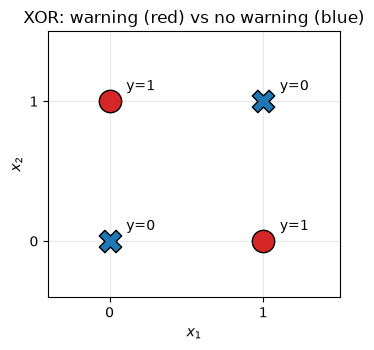

In [2]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

fig, ax = plt.subplots(figsize=(3.6, 3.6))
for (x1, x2), label in zip(X.tolist(), y.squeeze().tolist()):
    ax.scatter(x1, x2, s=260, marker="o" if label else "X",
               c="tab:red" if label else "tab:blue", edgecolors="k", zorder=3)
    ax.annotate(f"y={int(label)}", (x1, x2), textcoords="offset points", xytext=(12, 8))
ax.set(xlim=(-0.4, 1.5), ylim=(-0.4, 1.5), xlabel="$x_1$", ylabel="$x_2$",
       title="XOR: warning (red) vs no warning (blue)")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR / "xor_points.png", dpi=150); plt.show()

### Why one straight line cannot separate the classes

The positive points $(0,1), (1,0)$ sit on one diagonal and the negative points $(0,0), (1,1)$ on the other, so any line that puts both positives on one side also puts at least one negative there. Algebraically, a linear rule $w_1x_1 + w_2x_2 + b > 0$ would need $b \le 0$ (for $(0,0)$), $w_2 + b > 0$, $w_1 + b > 0$ and $w_1 + w_2 + b \le 0$. Adding the middle two gives $w_1 + w_2 + 2b > 0$, i.e. $w_1 + w_2 + b > -b \ge 0$, which contradicts the last condition.

### Prediction for a single affine map + sigmoid (logistic regression)

It cannot reach 4/4 — at most 3/4 points can be on the correct side of any line. More specifically, I predict that training with binary cross-entropy will drive it to $w = 0,\ b = 0$: by symmetry, at $w = b = 0$ every prediction is $0.5$, and the BCE gradient there is $\sum_i (p_i - y_i)\,x_i = 0.5\,[(0,0) - (0,1) - (1,0) + (1,1)] = 0$ and $\sum_i (p_i - y_i) = 0$. The loss is convex in $(w, b)$, so this stationary point is the global minimum. The model will output $p = 0.5$ for all four inputs and the loss will plateau at $\ln 2 \approx 0.693$ — it will learn to be maximally uncertain, not a "best line".

Testing the prediction:

In [3]:
def train(model, X, y, loss_fn, steps=5000, lr=1.0, record_every=None, seed=None):
    # Full-batch SGD. Returns a history dict (loss per step, early grad norms, optional W1 snapshots).
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    hist = {"loss": [], "grad_norm_W1": [], "W1": []}
    first = next(model.parameters())                      # the first layer's weight matrix
    for step in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X), y)                       # forward pass + scalar loss
        loss.backward()                                   # reverse-mode AD
        hist["loss"].append(loss.item())
        hist["grad_norm_W1"].append(first.grad.norm().item())
        if record_every and step % record_every == 0:
            hist["W1"].append(first.detach().clone())
        opt.step()                                        # parameter update
    with torch.no_grad():
        hist["final_loss"] = loss_fn(model(X), y).item()
    return hist

torch.manual_seed(SEED)
linear = nn.Linear(2, 1)
hist_lin = train(linear, X, y, nn.BCEWithLogitsLoss())
with torch.no_grad():
    p_lin = torch.sigmoid(linear(X))
print(f"initial loss {hist_lin['loss'][0]:.4f} -> final loss {hist_lin['final_loss']:.6f}   (ln 2 = {math.log(2):.6f})")
print("w =", linear.weight.data.squeeze().tolist(), " b =", linear.bias.item())
print("P(y=1|x) =", p_lin.squeeze().tolist())

initial loss 0.7168 -> final loss 0.693147   (ln 2 = 0.693147)
w = [1.1920928955078125e-07, 1.1920928955078125e-07]  b = -1.6391277313232422e-07
P(y=1|x) = [0.5, 0.5, 0.5, 0.5]


The prediction holds: the weights shrink to (numerically) zero, every probability is 0.5, and the loss sits at $\ln 2$.

A natural follow-up is "add depth". A *deep but linear* network (three hidden layers of 16 units, no activation) has 609 parameters but is still one affine map in disguise, since $W_3(W_2(W_1x + b_1) + b_2) + b_3 = W'x + b'$:

In [4]:
torch.manual_seed(SEED)
deep_linear = nn.Sequential(nn.Linear(2, 16), nn.Linear(16, 16), nn.Linear(16, 16), nn.Linear(16, 1))
hist_dl = train(deep_linear, X, y, nn.BCEWithLogitsLoss(), lr=0.1)
with torch.no_grad():
    p_dl = torch.sigmoid(deep_linear(X)).squeeze()
n_params = sum(p.numel() for p in deep_linear.parameters())
print(f"deep linear net: {n_params} parameters, final loss {hist_dl['final_loss']:.6f}, P(y=1|x) = {p_dl.tolist()}")

deep linear net: 609 parameters, final loss 0.693147, P(y=1|x) = [0.49999988079071045, 0.49999964237213135, 0.5000002980232239, 0.5000001192092896]


### Think About It — what scientific claim does XOR let us test with four data points?

That **representation, not parameter count, determines what a model can express**. XOR is the smallest problem whose classes are not linearly separable in input space, so it cleanly tests the claim that a network needs a *nonlinear intermediate representation* — hidden features in which the classes become linearly separable. The 609-parameter deep linear network fails exactly as the 3-parameter logistic regression does, because both have the wrong *kind* of representation (affine). With only four points there is no noise and no generalisation question to hide behind: either the representation can express the function or it cannot.

## Task 2 — Design the intelligent agent

### Model specification (written before asking the LLM)

| Component | Choice |
|---|---|
| Architecture | $2 \to 2 \to 1$: $\;a^{(1)} = W^{(1)}x + b^{(1)},\ h = f(a^{(1)}),\ z = W^{(2)}h + b^{(2)}$ |
| Parameters | $W^{(1)} \in \mathbb{R}^{2\times2},\ b^{(1)} \in \mathbb{R}^2,\ W^{(2)} \in \mathbb{R}^{1\times2},\ b^{(2)} \in \mathbb{R}$ (9 total) |
| Hidden activation $f$ | tanh (baseline); sigmoid and ReLU compared in Task 4D |
| Output | one logit $z$; $\;P(y=1\mid x) = \sigma(z)$; label $= [\sigma(z) > 0.5] = [z > 0]$ |
| Loss | mean binary cross-entropy over the 4 examples, via `BCEWithLogitsLoss` on the logit |
| Optimiser | full-batch gradient descent (SGD, lr = 1.0, 5000 steps), PyTorch default random init, fixed seed |

**1. Why is the hidden nonlinearity scientifically necessary?** Without it the network is $W^{(2)}(W^{(1)}x + b^{(1)}) + b^{(2)}$, a single affine function of $x$, so the decision boundary is a line and XOR is impossible (Task 1). The nonlinearity $f$ lets the hidden layer re-map the four inputs into a new space $h$ in which they *are* linearly separable, and the output layer then draws a line there.

**2. Why sigmoid + BCE for the output?** The target is a single yes/no answer, i.e. a Bernoulli variable. The sigmoid maps the logit to a valid probability in $(0,1)$, and BCE is exactly the negative log-likelihood of a Bernoulli model, so minimising it is maximum-likelihood estimation. The pairing also gives a clean gradient, $\partial L/\partial z = \sigma(z) - y$: it is large when the prediction is confidently wrong and does not vanish when the sigmoid saturates (unlike MSE on a sigmoid, whose gradient carries an extra $\sigma'(z)$ factor). Using `BCEWithLogitsLoss` on the logit computes $\log\sigma$ stably instead of taking the log of a rounded probability.

**3. Validation criteria (what counts as successful learning)**

1. **Loss:** final BCE $< 0.05$ and far below the linear-model plateau $\ln 2 \approx 0.693$; the loss curve should decrease overall.
2. **Predictions:** all four thresholded labels equal $y$, with probabilities on the correct side of 0.5 by a clear margin ($< 0.1$ or $> 0.9$).
3. **Gradients:** the first-layer gradient is non-zero at initialisation, matches a hand-derived backprop formula and a finite-difference estimate, and shrinks towards 0 at convergence.
4. **Representation:** the learned hidden activations $h$ for the four inputs are linearly separable by the output layer (inspected directly).
5. **Repeated runs:** report the success rate over several seeds rather than trusting one lucky run.

### Think About It — who decides what each hidden unit computes?

Nobody specifies targets for the hidden units; **backpropagation derives their learning signal from the output loss**. The error at the output, $\delta^{(2)} = \sigma(z) - y$, is sent backwards through the output weights, $\partial L/\partial h = W^{(2)\top}\delta^{(2)}$, and multiplied by the local derivative $f'(a^{(1)})$. Each hidden unit is therefore pushed in whichever direction most reduces the *final* loss, given what the other unit and the output layer are currently doing. What a hidden unit ends up computing (for XOR, typically something like OR and NAND/AND) is determined jointly by the task (via the loss), the architecture, and the random initialisation — and the initialisation matters, because it breaks the symmetry between the two units (Task 4C). We inspect the learned hidden features in Task 4A.

## Task 3 — Use an LLM to generate a first implementation

### The exact prompt used

> Generate minimal PyTorch code for the following model and dataset. Do not change the architecture or task.
>
> - Dataset: the four XOR examples, inputs `[[0,0],[0,1],[1,0],[1,1]]`, targets `[0,1,1,0]`, as float tensors of shape (4, 2) and (4, 1).
> - Model: a 2–2–1 network: `Linear(2, 2)` → tanh → `Linear(2, 1)`. The model's forward pass must return the **logit** (no sigmoid), because the loss is `BCEWithLogitsLoss`.
> - Initialisation: PyTorch's default random initialisation, after `torch.manual_seed(0)`.
> - Training: full-batch SGD, learning rate 1.0, 5000 steps, on the CPU.
> - After training, report the final loss, all four probabilities `sigmoid(logit)`, the thresholded labels (`probability > 0.5`), and the gradient tensor of the first layer's weight after one `backward()` call.
> - Set a random seed for reproducibility and explain each test in one sentence.

### The generated code (as returned)

```python
import torch
import torch.nn as nn

torch.manual_seed(0)
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)
        self.out = nn.Linear(2, 1)

    def forward(self, x):
        h = torch.tanh(self.hidden(x))
        return torch.sigmoid(self.out(h))          # <- (1)

model = XORNet()
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.SGD(model.parameters(), lr=1.0)

for step in range(5000):
    opt.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    opt.step()

print("final loss:", loss.item())                  # <- (2)
print("gradient of hidden weights:", model.hidden.weight.grad)
with torch.no_grad():
    logits = model(X)
    probs = torch.sigmoid(logits)
    print("probabilities:", probs.squeeze())
    print("labels:", (logits > 0.5).int().squeeze())   # <- (1)
```

### Inspection before running

- **Forward pass:** `model(X)`, i.e. `XORNet.forward`: `hidden` → tanh → `out`.
- **Scalar loss:** `loss_fn(model(X), y)`, the mean BCE over the four examples.
- **Reverse-mode AD:** `loss.backward()` fills `.grad` for all 9 parameters.
- **Parameter update:** `opt.step()`, after `opt.zero_grad()` has cleared the previous gradients.

### Two changes made before execution

1. **Double sigmoid.** `forward` applies `torch.sigmoid`, and then `BCEWithLogitsLoss` applies a second sigmoid internally, so the loss is computed on $\sigma(\sigma(z))$. Since $\sigma(\sigma(z)) \in (0.5, 0.731)$, the effective predicted probability can never go below 0.5 or above 0.731, and the lowest achievable loss is $\tfrac12[-\ln 0.5] + \tfrac12[-\ln 0.731] \approx 0.503$ instead of 0. The reporting is confused in the same way. The variable named `logits` actually holds probabilities $\sigma(z)$, and the printed "probabilities" are $\sigma(\sigma(z))$, which are always above 0.5. Thresholding them at 0.5, as the prompt asked, would label every input 1. The `logits > 0.5` line only gives sensible labels because it happens to threshold $\sigma(z)$. **Fix:** `forward` returns the raw logit, probabilities are `torch.sigmoid(logits)`, and labels are `probs > 0.5` (equivalently `logits > 0`). This is exactly what the prompt asked for, but the LLM did not follow it.
2. **Reported loss and gradient were one step stale.** `loss` and `.grad` are those computed *before* the last `opt.step()`, so they do not describe the final parameters. **Fix:** after training, recompute the loss with a fresh forward pass and record the gradients explicitly (initial and final), which the `train` helper in this notebook does.

The bug in (1) runs without any error. To show that it matters, here is the uncorrected model trained as written:

In [5]:
class XORNetAsGenerated(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)
        self.out = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.out(torch.tanh(self.hidden(x))))   # bug: sigmoid before BCEWithLogitsLoss

torch.manual_seed(SEED)
buggy = XORNetAsGenerated()
hist_bug = train(buggy, X, y, nn.BCEWithLogitsLoss())
with torch.no_grad():
    out = buggy(X)
floor = 0.5 * -math.log(0.5) + 0.5 * -math.log(torch.sigmoid(torch.tensor(1.0)).item())
print(f"final loss {hist_bug['final_loss']:.4f}   (best achievable with a double sigmoid: {floor:.4f})")
print("effective probabilities sigma(sigma(z)):", torch.sigmoid(out).squeeze().tolist())
print("labels from 'probs > 0.5' (as specified):", (torch.sigmoid(out) > 0.5).int().squeeze().tolist())
print("labels from 'logits > 0.5' (as written): ", (out > 0.5).int().squeeze().tolist(), "  target:", y.int().squeeze().tolist())

final loss 0.5983   (best achievable with a double sigmoid: 0.5032)
effective probabilities sigma(sigma(z)): [0.5000714659690857, 0.7308626770973206, 0.5000115036964417, 0.5000539422035217]
labels from 'probs > 0.5' (as specified): [1, 1, 1, 1]
labels from 'logits > 0.5' (as written):  [0, 1, 0, 0]   target: [0, 1, 1, 0]


As written, the model trains without error and its loss decreases (0.70 → 0.60), so nothing *looks* broken. But it cannot solve the task. Its effective probabilities are about 0.5 for three inputs and 0.73 for one, the specified thresholding labels everything 1, and even the accidental `logits > 0.5` labels get only 3 of 4 right.

### Think About It — what can be verified from the code, and what needs execution?

**Verifiable by reading the code (static):**
- the dataset matches the truth table, with float dtype and shapes (4, 2)/(4, 1);
- the architecture is 2–2–1 with the chosen activation;
- the output and loss agree (logit + `BCEWithLogitsLoss`, *no* extra sigmoid);
- the thresholding rule is right;
- the order `zero_grad` → forward → loss → `backward` → `step` is correct;
- a seed is set and the requested quantities are printed.

This is how bug (1) was caught before anything ran.

**Requires execution and measurement:**
- whether the loss actually decreases and reaches a low value;
- whether all four labels come out right;
- whether this seed lands in a local minimum (the 2–2–1 XOR loss surface has them);
- the actual size of the gradients, and whether they vanish;
- that autograd's gradient matches the chain-rule derivation;
- whether the zero-init rows stay identical;
- how the activations compare;
- whether softmax is numerically stable.

The code tells you *what experiment* is being run; only execution tells you *what happened*.

## Task 4 — Execute, test, and diagnose

The corrected implementation, used for the rest of the lab:

In [6]:
ACTIVATIONS = {"sigmoid": nn.Sigmoid, "tanh": nn.Tanh, "relu": nn.ReLU}

def make_net(activation="tanh", seed=SEED, n_out=1, n_hidden=2):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(2, n_hidden), ACTIVATIONS[activation](), nn.Linear(n_hidden, n_out))

bce = nn.BCEWithLogitsLoss()

def evaluate(model):
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        labels = (probs > 0.5).float()
    return probs.squeeze(), labels.squeeze(), bool((labels == y).all())

### Part A — Basic learning check

In [7]:
net = make_net("tanh")
init_state = copy.deepcopy(net.state_dict())
hist = train(net, X, y, bce)
probs, labels, ok = evaluate(net)

print(f"initial loss: {hist['loss'][0]:.4f}")
print(f"final loss:   {hist['final_loss']:.6f}\n")
print(" x1 x2 | y | P(y=1|x) | label")
for (x1, x2), t, p, l in zip(X.int().tolist(), y.int().squeeze().tolist(), probs.tolist(), labels.int().tolist()):
    print(f"  {x1}  {x2} | {t} |  {p:.4f}  |   {l}")
print("\nAll four labels correct:", ok)

initial loss: 0.7152
final loss:   0.000640

 x1 x2 | y | P(y=1|x) | label
  0  0 | 0 |  0.0008  |   0
  0  1 | 1 |  0.9996  |   1
  1  0 | 1 |  0.9996  |   1
  1  1 | 0 |  0.0009  |   0

All four labels correct: True


In [8]:
# Validation criterion 4: what did the hidden layer learn?
with torch.no_grad():
    H = net[1](net[0](X))
print("hidden activations h = tanh(W1 x + b1):")
for (x1, x2), h, t in zip(X.int().tolist(), H.tolist(), y.int().squeeze().tolist()):
    print(f"  x=({x1},{x2})  h=({h[0]:+.3f}, {h[1]:+.3f})  y={t}")
print("\nW1 =", net[0].weight.data.tolist(), "\nb1 =", net[0].bias.data.tolist())
print("W2 =", net[2].weight.data.tolist(), "  b2 =", net[2].bias.data.tolist())

hidden activations h = tanh(W1 x + b1):
  x=(0,0)  h=(-0.963, +1.000)  y=0
  x=(0,1)  h=(+0.972, +0.936)  y=1
  x=(1,0)  h=(+0.972, +0.936)  y=1
  x=(1,1)  h=(+1.000, -0.954)  y=0

W1 = [[4.103612422943115, 4.103998184204102], [-3.5811734199523926, -3.581270456314087]] 
b1 = [-1.9790897369384766, 5.28446102142334]
W2 = [[7.928296089172363, 7.948674201965332]]   b2 = [-7.409494876861572]


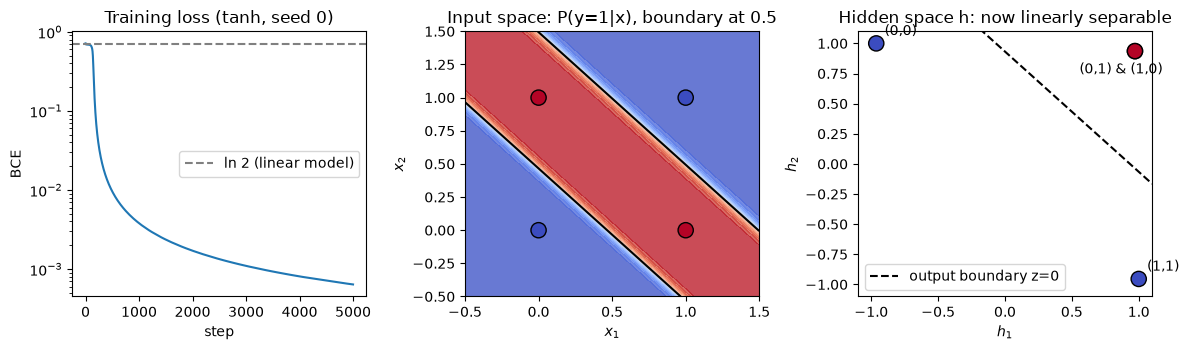

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].semilogy(hist["loss"]); axes[0].axhline(math.log(2), ls="--", c="gray", label="ln 2 (linear model)")
axes[0].set(title="Training loss (tanh, seed 0)", xlabel="step", ylabel="BCE"); axes[0].legend()

g = torch.linspace(-0.5, 1.5, 200)
gx, gy = torch.meshgrid(g, g, indexing="xy")
with torch.no_grad():
    pz = torch.sigmoid(net(torch.stack([gx.ravel(), gy.ravel()], 1))).reshape(gx.shape)
axes[1].contourf(gx, gy, pz, levels=20, cmap="coolwarm", alpha=0.8)
axes[1].contour(gx, gy, pz, levels=[0.5], colors="k")
axes[1].scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="coolwarm", edgecolors="k", s=120)
axes[1].set(title="Input space: P(y=1|x), boundary at 0.5", xlabel="$x_1$", ylabel="$x_2$")

axes[2].scatter(H[:, 0], H[:, 1], c=y.squeeze(), cmap="coolwarm", edgecolors="k", s=120)
for text, i in [("(0,0)", 0), ("(0,1) & (1,0)", 1), ("(1,1)", 3)]:   # (0,1) and (1,0) map to the same h
    axes[2].annotate(text, H[i].tolist(), textcoords="offset points", xytext=(-40, -16) if i == 1 else (6, 6))
w, b = net[2].weight.data.squeeze(), net[2].bias.item()
hs = torch.linspace(-1.1, 1.1, 10)
axes[2].plot(hs, -(w[0] * hs + b) / w[1], "k--", label="output boundary z=0")
axes[2].set(title="Hidden space h: now linearly separable", xlabel="$h_1$", ylabel="$h_2$", xlim=(-1.1, 1.1), ylim=(-1.1, 1.1))
axes[2].legend(loc="lower left")
fig.tight_layout(); fig.savefig(OUT_DIR / "xor_learning.png", dpi=150); plt.show()

**Validation criterion 5 — repeated runs.** A single success could be a lucky seed. The same design was retrained from 20 seeds:

In [10]:
def success_rate(activation, seeds=range(20), steps=5000):
    results = []
    for s in seeds:
        m = make_net(activation, seed=s)
        h = train(m, X, y, bce, steps=steps)
        results.append((s, h["final_loss"], evaluate(m)[2]))
    return results

tanh_runs = success_rate("tanh")
wins = [s for s, _, ok in tanh_runs if ok]
print(f"tanh 2-2-1: {len(wins)}/20 seeds reach 4/4 correct")
print("final losses of the failed runs:", sorted({round(l, 4) for _, l, ok in tanh_runs if not ok}))

tanh 2-2-1: 11/20 seeds reach 4/4 correct
final losses of the failed runs: [0.3468, 0.347]


**Result:** seed 0 meets all the validation criteria. The loss falls from 0.715 to 0.0006, all four probabilities are within 0.001 of their targets, and the gradient norm shrinks from 0.06 to about $10^{-4}$ (Part B). The hidden layer has learned two interpretable features:
- $h_1 \approx -1$ only for $(0,0)$, so it computes **OR**;
- $h_2 \approx -1$ only for $(1,1)$, so it computes **NAND**.

XOR = OR ∧ NAND, which is linearly separable in $(h_1, h_2)$: the output unit fires only when both features are high. This is exactly the representation that Task 1 said a linear model lacks.

Repeated runs show this is *not* guaranteed. The minimal 2–2–1 network solves XOR from only 11 of 20 seeds. Every failed run stalls at loss $\approx 0.347 = \tfrac12\ln 2$: two inputs are fit perfectly and the other two are left at $p = 0.5$. The tiny network has local minima and saddle regions, which is a known property of 2–2–1 XOR. Because of the Task 4 instructions, I did **not** change the task or architecture to hide this. The justified engineering settings (fixed seed, lr, steps) were kept, and the variability is reported. Adding hidden units (an architecture change) would make success far more reliable.

### Part B — Backpropagation check

`parameter.grad` after `loss.backward()` holds $\partial L/\partial \theta$ evaluated at the current parameters. For the first layer, `net[0].weight.grad[j, k]` $= \partial L / \partial W^{(1)}_{jk}$: how much the mean loss would change per unit increase of the weight from input $k$ to hidden unit $j$. It is a $2\times 2$ tensor with the same shape as $W^{(1)}$.

Backprop by hand for this network, with $N = 4$ examples:

$$\delta^{(2)}_i = \frac{\sigma(z_i) - y_i}{N},\quad
\frac{\partial L}{\partial W^{(2)}} = \sum_i \delta^{(2)}_i h_i^\top,\quad
\delta^{(1)}_i = \big(W^{(2)\top}\delta^{(2)}_i\big)\odot f'(a^{(1)}_i),\quad
\frac{\partial L}{\partial W^{(1)}} = \sum_i \delta^{(1)}_i x_i^\top.$$

Three independent checks of autograd at the **initial** parameters (where the gradient is large):

In [11]:
def grad_W1(model, X, y):
    model.zero_grad()
    bce(model(X), y).backward()
    return model[0].weight.grad.clone()

net0 = make_net("tanh")                       # same initial parameters as Part A
g_auto = grad_W1(net0, X, y)
print("autograd  dL/dW1 =\n", g_auto)

# (1) manual backprop with the chain rule
with torch.no_grad():
    W1, b1, W2, b2 = net0[0].weight, net0[0].bias, net0[2].weight, net0[2].bias
    a1 = X @ W1.T + b1
    h = torch.tanh(a1)
    z = h @ W2.T + b2
    d2 = (torch.sigmoid(z) - y) / len(X)          # dL/dz, shape (4, 1)
    d1 = (d2 @ W2) * (1 - h ** 2)                 # dL/da1, tanh'(a) = 1 - tanh(a)^2
    g_manual = d1.T @ X
print("\nmanual    dL/dW1 =\n", g_manual)

# (2) central finite differences in float64
net64 = copy.deepcopy(net0).double()
X64, y64 = X.double(), y.double()
g_fd = torch.zeros_like(g_auto, dtype=torch.float64)
eps = 1e-6
for j in range(2):
    for k in range(2):
        with torch.no_grad():
            net64[0].weight[j, k] += eps;     lp = bce(net64(X64), y64).item()
            net64[0].weight[j, k] -= 2 * eps; lm = bce(net64(X64), y64).item()
            net64[0].weight[j, k] += eps
        g_fd[j, k] = (lp - lm) / (2 * eps)
print("\nfinite-difference dL/dW1 =\n", g_fd.float())

# (3) mean loss => gradient is the mean of per-example gradients
g_each = torch.stack([grad_W1(net0, X[i:i+1], y[i:i+1]) for i in range(4)])
print("\nper-example gradients (one 2x2 block per example):\n", g_each)
print("\nmean of per-example gradients =\n", g_each.mean(0))

assert torch.allclose(g_auto, g_manual, atol=1e-7)
assert torch.allclose(g_auto.double(), g_fd, atol=1e-6)
assert torch.allclose(g_auto, g_each.mean(0), atol=1e-7)
print(f"\n||dL/dW1|| at init = {g_auto.norm():.4f}, at the last training step = {hist["grad_norm_W1"][-1]:.2e}")
print("All three checks agree with autograd.")

autograd  dL/dW1 =
 tensor([[ 0.0005,  0.0006],
        [-0.0426, -0.0448]])

manual    dL/dW1 =
 tensor([[ 0.0005,  0.0006],
        [-0.0426, -0.0448]])

finite-difference dL/dW1 =
 tensor([[ 0.0005,  0.0006],
        [-0.0426, -0.0448]])

per-example gradients (one 2x2 block per example):
 tensor([[[ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        [[ 0.0000,  0.0078],
         [ 0.0000, -0.2822]],

        [[ 0.0074,  0.0000],
         [-0.2734,  0.0000]],

        [[-0.0053, -0.0053],
         [ 0.1031,  0.1031]]])

mean of per-example gradients =
 tensor([[ 0.0005,  0.0006],
        [-0.0426, -0.0448]])

||dL/dW1|| at init = 0.0618, at the last training step = 9.14e-05
All three checks agree with autograd.


**Interpretation.** Autograd, the hand-derived chain rule and finite differences agree to about $10^{-7}$, so `backward()` computes exactly the backpropagation derived in the lecture. The gradient norm falls by nearly three orders of magnitude (0.062 → 9 × 10⁻⁵) between initialisation and convergence.

**Why the gradient is the average of the example-wise gradients.** `BCEWithLogitsLoss` uses `reduction="mean"`, so $L = \frac{1}{N}\sum_{i=1}^N \ell_i(\theta)$. Differentiation is linear, so $\nabla_\theta L = \frac1N\sum_i \nabla_\theta \ell_i$. Check (3) confirms this numerically. It also shows the examples disagreeing: the per-example gradients point in different directions, and the update follows their average. The example $(0,0)$ contributes exactly zero to $\partial L/\partial W^{(1)}$, because the weight gradient is $\delta^{(1)} x^\top$ and $x = 0$. Only the bias can learn from that input. (With `reduction="sum"` the gradient would be $N$ times larger, which is equivalent to multiplying the learning rate by $N$.)

### Part C — Symmetry experiment

The same architecture and training settings, but every weight and bias is set to zero before training. The two rows of $W^{(1)}$ (one per hidden unit) are tracked over training. Two extra variants separate *zero* from *identical*: a sigmoid hidden layer (where $f(0) = 0.5 \neq 0$), and a tanh layer where every weight is set to the same non-zero constant 0.5.

In [12]:
def constant_init(model, value):
    with torch.no_grad():
        for p in model.parameters():
            p.fill_(value)
    return model

symmetry_runs = {
    "tanh, all zeros":     constant_init(make_net("tanh"), 0.0),
    "sigmoid, all zeros":  constant_init(make_net("sigmoid"), 0.0),
    "tanh, all 0.5":       constant_init(make_net("tanh"), 0.5),
}
sym_hist = {}
for name, m in symmetry_runs.items():
    sym_hist[name] = train(m, X, y, bce, record_every=1000)
    probs_s, labels_s, ok_s = evaluate(m)
    print(f"--- {name}: final loss {sym_hist[name]['final_loss']:.4f}, 4/4 correct: {ok_s}, probs {probs_s.numpy().round(3)}")
    for step, W in zip(range(0, 5000, 1000), sym_hist[name]["W1"]):
        print(f"   step {step:>4}: row0={W[0].numpy().round(4)}  row1={W[1].numpy().round(4)}  identical={torch.equal(W[0], W[1])}")

--- tanh, all zeros: final loss 0.6931, 4/4 correct: False, probs [0.5 0.5 0.5 0.5]
   step    0: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 1000: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 2000: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 3000: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 4000: row0=[0. 0.]  row1=[0. 0.]  identical=True


--- sigmoid, all zeros: final loss 0.6931, 4/4 correct: False, probs [0.5 0.5 0.5 0.5]
   step    0: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 1000: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 2000: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 3000: row0=[0. 0.]  row1=[0. 0.]  identical=True
   step 4000: row0=[0. 0.]  row1=[0. 0.]  identical=True


--- tanh, all 0.5: final loss 0.4778, 4/4 correct: False, probs [0.001 0.667 0.667 0.667]
   step    0: row0=[0.5 0.5]  row1=[0.5 0.5]  identical=True
   step 1000: row0=[3.9767 3.9767]  row1=[3.9767 3.9767]  identical=True
   step 2000: row0=[4.4463 4.4463]  row1=[4.4463 4.4463]  identical=True
   step 3000: row0=[4.7108 4.7108]  row1=[4.7108 4.7108]  identical=True
   step 4000: row0=[4.8951 4.8951]  row1=[4.8951 4.8951]  identical=True


**Result.** In all three runs the two rows of $W^{(1)}$ stay **exactly** identical (bit-for-bit) throughout training, and no run solves XOR:

- **All zeros (tanh *and* sigmoid): nothing moves at all.** Every one of the 9 gradients is exactly zero at step 0, so this is a stationary point. With all weights zero the output is $z = 0$, so $p = 0.5$ for every input. The output-layer gradients are then $\sum_i(p_i - y_i) = 4(0.5) - 2 = 0$ (for $b^{(2)}$) and $\sum_i (p_i - y_i)\,h_i = h\sum_i(p_i - y_i) = 0$ (for $W^{(2)}$, since every $h_i$ is the same). The hidden-layer gradient is multiplied by $W^{(2)} = 0$. Gradient descent stays at loss $\ln 2$ forever, whatever the activation.
- **tanh, all 0.5 (identical but non-zero): the weights move, but in lock-step.** Both rows grow from 0.5 to about 4.9 while remaining exactly equal. The network ends at loss 0.478 with $p \approx (0.001, 0.667, 0.667, 0.667)$: it has learned a single OR-like feature, and with one effective hidden unit it cannot separate $(1,1)$ from the positives. So the problem is **symmetry**, not zero. Zero is just the most extreme symmetric point.

**Explanation.** If both hidden units start with the same incoming weights, bias and outgoing weight, they compute the same pre-activation $a_1 = a_2$ on every input, so the same output $h_1 = h_2$. They then receive the same backpropagated error $\delta^{(1)}_1 = \delta^{(1)}_2$, and hence the same gradient and the same update. By induction they are identical after every step. The network behaves as if it had **one** hidden unit, and a single hidden unit feeding a monotone output can only produce a boundary of the form $f(w\cdot x + b) = c$, which is a straight line. So XOR stays unsolvable. Random initialisation is what breaks the symmetry and lets the units specialise.

### Part D — Activation experiment

Same seed, same initial weights, same optimiser and number of steps. Only the hidden activation changes. The "early" gradient norm is $\lVert\nabla_{W^{(1)}}L\rVert_2$ at step 0, with the mean over the first 100 steps as a second view.

In [13]:
act_hist, act_models = {}, {}
rows = []
for act in ["sigmoid", "tanh", "relu"]:
    m = make_net(act)
    h = train(m, X, y, bce)
    act_hist[act], act_models[act] = h, m
    rows.append((act, h["final_loss"], evaluate(m)[2], h["grad_norm_W1"][0], np.mean(h["grad_norm_W1"][:100])))

print(f"{'Hidden activation':<18}{'Final loss':>11}{'4/4 correct?':>14}{'||grad W1|| step 0':>20}{'mean first 100':>16}")
for act, loss, ok, g0, g100 in rows:
    print(f"{act:<18}{loss:>11.4f}{'yes' if ok else 'no':>14}{g0:>20.4f}{g100:>16.4f}")

Hidden activation  Final loss  4/4 correct?  ||grad W1|| step 0  mean first 100
sigmoid                0.0061           yes              0.0009          0.0022
tanh                   0.0006           yes              0.0618          0.0089
relu                   0.4774            no              0.0017          0.0687


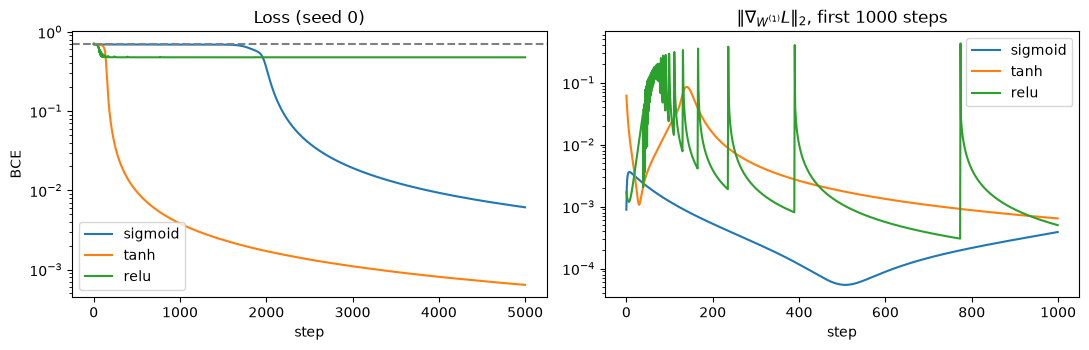

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for act, h in act_hist.items():
    axes[0].semilogy(h["loss"], label=act)
    axes[1].semilogy(h["grad_norm_W1"][:1000], label=act)
axes[0].axhline(math.log(2), ls="--", c="gray")
axes[0].set(title="Loss (seed 0)", xlabel="step", ylabel="BCE"); axes[0].legend()
axes[1].set(title="$\\|\\nabla_{W^{(1)}} L\\|_2$, first 1000 steps", xlabel="step"); axes[1].legend()
fig.tight_layout(); fig.savefig(OUT_DIR / "activation_comparison.png", dpi=150); plt.show()

Seed 0 alone is one sample, so the same comparison was repeated over 20 seeds. Each seed gives every activation the same initial weights.

In [15]:
multi = {}
for act in ["sigmoid", "tanh", "relu"]:
    runs, g0s = [], []
    for s in range(20):
        m = make_net(act, seed=s)
        h = train(m, X, y, bce)
        runs.append(evaluate(m)[2]); g0s.append(h["grad_norm_W1"][0])
    multi[act] = (sum(runs), float(np.median(g0s)))
print(f"{'activation':<10}{'solved (of 20 seeds)':>22}{'median ||grad W1|| at step 0':>30}")
for act, (n_ok, g0) in multi.items():
    print(f"{act:<10}{n_ok:>22}{g0:>30.4f}")

activation  solved (of 20 seeds)  median ||grad W1|| at step 0
sigmoid                       15                        0.0036
tanh                          11                        0.0211
relu                           4                        0.0175


**Diagnosing small gradients (Think About It).** Saturated sigmoid units and dead ReLU units both give tiny gradients, but through different mechanisms. You can tell them apart by looking at the pre-activations $a^{(1)}$ and the local derivative $f'(a^{(1)})$ on each input:

In [16]:
def diagnose(model, act):
    with torch.no_grad():
        a = model[0](X)
        if act == "sigmoid":
            s = torch.sigmoid(a); d = s * (1 - s)
        elif act == "tanh":
            d = 1 - torch.tanh(a) ** 2
        else:
            d = (a > 0).float()
    print(f"--- {act}: pre-activations a (rows = inputs, cols = hidden units) and local derivative f'(a)")
    for (x1, x2), ai, di in zip(X.int().tolist(), a.tolist(), d.tolist()):
        print(f"   x=({x1},{x2})  a=({ai[0]:+7.3f}, {ai[1]:+7.3f})   f'(a)=({di[0]:.4f}, {di[1]:.4f})")
    if act == "relu":
        dead = [j for j in range(a.shape[1]) if (a[:, j] <= 0).all()]
        print("   dead units (a <= 0 on all four inputs):", dead)

for act in ["sigmoid", "relu"]:
    diagnose(make_net(act), act)          # at initialisation
    diagnose(act_models[act], act)        # after training

--- sigmoid: pre-activations a (rows = inputs, cols = hidden units) and local derivative f'(a)
   x=(0,0)  a=( -0.272,  +0.190)   f'(a)=(0.2454, 0.2478)
   x=(0,1)  a=( +0.107,  -0.331)   f'(a)=(0.2493, 0.2433)
   x=(1,0)  a=( -0.278,  -0.392)   f'(a)=(0.2452, 0.2406)
   x=(1,1)  a=( +0.102,  -0.913)   f'(a)=(0.2494, 0.2044)
--- sigmoid: pre-activations a (rows = inputs, cols = hidden units) and local derivative f'(a)
   x=(0,0)  a=( -3.441, +10.173)   f'(a)=(0.0301, 0.0000)
   x=(0,1)  a=( +4.081,  +3.388)   f'(a)=(0.0163, 0.0316)
   x=(1,0)  a=( +4.080,  +3.388)   f'(a)=(0.0163, 0.0316)
   x=(1,1)  a=(+11.602,  -3.397)   f'(a)=(0.0000, 0.0314)
--- relu: pre-activations a (rows = inputs, cols = hidden units) and local derivative f'(a)
   x=(0,0)  a=( -0.272,  +0.190)   f'(a)=(0.0000, 1.0000)
   x=(0,1)  a=( +0.107,  -0.331)   f'(a)=(1.0000, 0.0000)
   x=(1,0)  a=( -0.278,  -0.392)   f'(a)=(0.0000, 0.0000)
   x=(1,1)  a=( +0.102,  -0.913)   f'(a)=(1.0000, 0.0000)
   dead units (a <= 0 

**Interpretation.**

| Hidden activation | Final loss | 4/4 correct? | Early $\lVert\nabla_{W^{(1)}}L\rVert_2$ (step 0) | Solved, 20 seeds |
|---|---|---|---|---|
| Sigmoid | 0.0061 | yes | 0.0009 | 15/20 |
| Tanh | 0.0006 | yes | 0.0618 | 11/20 |
| ReLU | 0.4774 | no | 0.0017 | 4/20 |

- **tanh** has by far the largest early gradient (about 70× sigmoid's on seed 0). $\tanh'(0) = 1$, and its outputs are zero-centred, so the backpropagated error is barely shrunk. It is also the fastest: its loss is below 0.1 by step 183, and it reaches the lowest final loss.
- **sigmoid** starts with a tiny gradient (0.0009). $\sigma'(a) \le 0.25$ scales every error passing back through the layer by at most 1/4, and the hidden outputs sit near 0.5 rather than 0. On seed 0 the loss stays on the $\ln 2$ plateau for about 2000 steps (step 1000: 0.693) before it escapes and solves XOR. At initialisation the pre-activations are moderate ($|a| < 1$, $\sigma'(a) \approx 0.24$), so the early gradient is small because of the derivative bound, **not** saturation. After training, some pre-activations are around $\pm 10$ with $\sigma'(a) \approx 0$: those units are now saturated on specific inputs, which is how the network holds its confident outputs.
- **ReLU** fails on seed 0, stuck at loss 0.477. At initialisation no unit is dead, but unit 1 is active on only one input, $(0,0)$. During training its pre-activations are pushed below 0 on all four inputs. The unit is then **dead**: $f'(a) = 0$ exactly everywhere, so it gets no gradient and can never recover. The network is left with one effective hidden unit, which cannot represent XOR (Part C). Its average gradient over the first 100 steps is actually the *largest* of the three (0.069), so a large early gradient is no guarantee of success.
- **Over 20 seeds the ranking changes:** sigmoid solves the most seeds (15), then tanh (11), then ReLU (4). Tanh learns fastest when it succeeds, but in this tiny network sigmoid's slower, smaller steps fall into the bad plateaus less often.
- **Telling the two small-gradient mechanisms apart (Think About It):**
  - *Saturation* shows up as **large** $|a|$ with $f(a)$ near 0 or 1, and $f'(a)$ small but non-zero. It is usually confined to some inputs, and the unit still gets gradient from the others (the trained sigmoid net above).
  - A *dead ReLU* shows up as $a \le 0$ on **all** inputs, with $f'(a) = 0$ exactly and an exactly zero gradient row for that unit (the trained ReLU net above).

  Inspecting the pre-activations per input, as the diagnostic does, distinguishes the two immediately.

These are observations about four points, a 2–2–1 network, one learning rate and plain SGD. They do **not** show that one activation is universally best. Tanh wins on speed, sigmoid on reliability over seeds, and ReLU, which does poorly here, is the standard choice in wide deep networks, where a few dead units do not matter and non-saturation helps. What the experiment does show is *how* the activation enters the gradient, through $f'(a^{(1)})$ in $\delta^{(1)}$, and the two different ways that factor can become small.

## Task 5 — Three-class extension

| Class | Meaning |
|---|---|
| 0 | both sensors inactive, $(0,0)$ |
| 1 | sensors disagree, $(0,1)$ or $(1,0)$ |
| 2 | both sensors active, $(1,1)$ |

### Predictions before accepting the change

1. **Shape of the final weight matrix:** $W^{(2)} \in \mathbb{R}^{3\times 2}$ (3 classes × 2 hidden units), plus $b^{(2)} \in \mathbb{R}^3$. In PyTorch, `nn.Linear(2, 3).weight.shape == (3, 2)`.
2. **Logits per example:** 3, so the model output has shape (4, 3).
3. **Why softmax probabilities sum to one:** $p_k = e^{z_k}/\sum_j e^{z_j}$. Every term is positive, and the numerators summed over $k$ equal the shared denominator, so $\sum_k p_k = 1$ by construction.
4. **Why the logit gradient is $p - y$:** with one-hot $y$, $\ell = -\sum_k y_k \log p_k = -z_c + \log\sum_j e^{z_j}$ for the true class $c$. Differentiating, $\partial\ell/\partial z_k = -[k=c] + e^{z_k}/\sum_j e^{z_j} = p_k - y_k$. For a mean over $N$ examples, the gradient is divided by $N$.

### LLM prompt for the modification

> Modify only the output layer and the loss of the previous code. Keep the 2-unit tanh hidden layer, the data inputs, the seed and the optimiser unchanged. Replace `Linear(2, 1)` with `Linear(2, 3)`, and use class-index targets `[0, 1, 1, 2]` with `nn.CrossEntropyLoss`, which takes the raw logits (no softmax in the model). After training, print the softmax probabilities for all four inputs, the predicted class (argmax), and the gradient of the loss with respect to the logits.

The accepted change (only the output layer, the targets and the loss differ from the binary model):

In [17]:
y3 = torch.tensor([0, 1, 1, 2])                      # class indices, shape (4,)
net3 = make_net("tanh", n_out=3)                     # Linear(2,2) -> tanh -> Linear(2,3)
ce = nn.CrossEntropyLoss()                           # log-softmax + NLL on raw logits, mean over examples
print("final weight matrix shape:", tuple(net3[2].weight.shape), "| bias:", tuple(net3[2].bias.shape))
print("logits shape:", tuple(net3(X).shape))

hist3 = train(net3, X, y3, ce)
with torch.no_grad():
    logits3 = net3(X)
    P3 = torch.softmax(logits3, dim=1)
print(f"\nloss {hist3['loss'][0]:.4f} -> {hist3['final_loss']:.6f}\n")
print(" x1 x2 | class | P(0)    P(1)    P(2)   | argmax | row sum")
for (x1, x2), c, p in zip(X.int().tolist(), y3.tolist(), P3):
    print(f"  {x1}  {x2} |   {c}   | {p[0]:.4f}  {p[1]:.4f}  {p[2]:.4f} |   {p.argmax().item()}    | {p.sum().item():.7f}")
print("\nAll four classified correctly:", bool((P3.argmax(1) == y3).all()))

final weight matrix shape: (3, 2) | bias: (3,)
logits shape: (4, 3)



loss 1.0591 -> 0.000256

 x1 x2 | class | P(0)    P(1)    P(2)   | argmax | row sum
  0  0 |   0   | 0.9997  0.0003  0.0000 |   0    | 1.0000000
  0  1 |   1   | 0.0001  0.9998  0.0001 |   1    | 1.0000000
  1  0 |   1   | 0.0001  0.9998  0.0001 |   1    | 1.0000000
  1  1 |   2   | 0.0000  0.0003  0.9997 |   2    | 1.0000000

All four classified correctly: True


In [18]:
# Verify p - y numerically for one example and for the batch.
print("softmax vector for x=(0,1):", P3[1].tolist(), " sum =", P3[1].sum().item())

net3_init = make_net("tanh", n_out=3)
logits = net3_init(X)
logits.retain_grad()
ce(logits, y3).backward()
Y = nn.functional.one_hot(y3, 3).float()
expected = (torch.softmax(logits, 1) - Y) / len(X)
print("\ndL/dlogits from autograd:\n", logits.grad)
print("(p - y) / N:\n", expected.detach())
assert torch.allclose(logits.grad, expected, atol=1e-7)
print("Each row sums to", logits.grad.sum(1).tolist(), " (probability mass moves between classes, total unchanged)")

softmax vector for x=(0,1): [7.440744229825214e-05, 0.9997856020927429, 0.00013999617658555508]  sum = 1.0

dL/dlogits from autograd:
 tensor([[-0.1790,  0.0825,  0.0964],
        [ 0.0599, -0.1674,  0.1076],
        [ 0.0562, -0.1694,  0.1132],
        [ 0.0501,  0.0804, -0.1305]])
(p - y) / N:
 tensor([[-0.1790,  0.0825,  0.0964],
        [ 0.0599, -0.1674,  0.1076],
        [ 0.0562, -0.1694,  0.1132],
        [ 0.0501,  0.0804, -0.1305]])
Each row sums to [7.450580596923828e-09, 0.0, -7.450580596923828e-09, 0.0]  (probability mass moves between classes, total unchanged)


**Result.** The three-class model classifies all four inputs correctly, every softmax row sums to 1 up to float32 rounding, and autograd's logit gradient equals $(p - y)/N$ exactly.

A side observation: unlike XOR, this three-class task is **linearly separable** by a softmax classifier, because the class is just $x_1 + x_2$, the number of active sensors. The logits $z = (0,\; c s - \tfrac{c}{2},\; 2cs - 2c)$ with $s = x_1 + x_2$ separate it for any $c > 0$. Splitting XOR's class 0 into "both off" and "both on" removes the need for the hidden nonlinearity:

In [19]:
torch.manual_seed(SEED)
softmax_linear = nn.Linear(2, 3)
h_sl = train(softmax_linear, X, y3, ce)
with torch.no_grad():
    pred = softmax_linear(X).argmax(1)
print(f"linear softmax (no hidden layer): final loss {h_sl['final_loss']:.4f}, predictions {pred.tolist()} vs targets {y3.tolist()}")

linear softmax (no hidden layer): final loss 0.0050, predictions [0, 1, 1, 2] vs targets [0, 1, 1, 2]


### Optional diagnostic — shift invariance and numerical stability

In [20]:
z = logits3[1].detach()
print("logits:", z.tolist())
print("softmax(z)       :", torch.softmax(z, 0).tolist())
print("softmax(z + 100) :", torch.softmax(z + 100, 0).tolist())
print("max abs difference:", (torch.softmax(z, 0) - torch.softmax(z + 100, 0)).abs().max().item())

def naive_softmax(v):
    e = torch.exp(v)
    return e / e.sum()

def stable_softmax(v):
    e = torch.exp(v - v.max())
    return e / e.sum()

for shift in [0, 100, 1000]:
    print(f"shift {shift:>4}: naive = {naive_softmax(z + shift).tolist()}   stable = {stable_softmax(z + shift).tolist()}")

logits: [-3.945903778076172, 5.559836387634277, -3.313844680786133]
softmax(z)       : [7.440744229825214e-05, 0.9997856020927429, 0.00013999617658555508]
softmax(z + 100) : [7.440708577632904e-05, 0.9997856020927429, 0.00013999630755279213]
max abs difference: 3.5652192309498787e-10
shift    0: naive = [7.440743502229452e-05, 0.9997855424880981, 0.00013999616203363985]   stable = [7.440744229825214e-05, 0.9997856020927429, 0.00013999617658555508]
shift  100: naive = [nan, nan, nan]   stable = [7.440708577632904e-05, 0.9997856020927429, 0.00013999630755279213]
shift 1000: naive = [nan, nan, nan]   stable = [7.440765330102295e-05, 0.9997856020927429, 0.00013999950897414237]


**Why the shift does not matter mathematically:** $\dfrac{e^{z_k + c}}{\sum_j e^{z_j + c}} = \dfrac{e^c e^{z_k}}{e^c \sum_j e^{z_j}} = \dfrac{e^{z_k}}{\sum_j e^{z_j}}$, so softmax depends only on *differences* between logits. PyTorch's softmax of $z + 100$ matches softmax of $z$ to within $4 \times 10^{-10}$, which is floating-point round-off.

**Why stable implementations subtract the maximum:** $e^{z}$ overflows float32 for $z \gtrsim 88.7$. The naive version already breaks at a shift of +100 (the largest logit becomes 105.6, so $e^{105.6} = $ `inf` and `inf/inf = nan`), and very negative logits underflow to `0/0` in the same way. Subtracting $\max_j z_j$ uses the invariance above to choose $c = -\max_j z_j$. The largest exponent is then $e^0 = 1$, so nothing overflows and the denominator is at least 1. PyTorch's `softmax` and `CrossEntropyLoss` (via log-sum-exp) already do this, which is why the model should output raw logits and let the loss function handle normalisation.

### Think About It — what stays the same with a vocabulary of tens of thousands?

**Mathematically unchanged:**
- the softmax formula and the fact that its outputs sum to 1;
- cross-entropy as the negative log-likelihood of the correct class;
- the logit gradient $p - y$;
- shift invariance and the max-subtraction trick;
- averaging the gradient over a batch;
- backpropagation through the layers below.

Next-token prediction in an LLM is this same three-class computation with $K = |V|$.

**What changes dramatically:**
- **Output layer size:** it becomes a $d \times |V|$ matrix (for example, 4096 × 50,000 ≈ 200M parameters), often the largest single layer, with correspondingly expensive compute and memory for the logits.
- **Hidden representation:** 2 tanh units are replaced by deep transformer stacks with embeddings, attention and residual connections.
- **Inputs:** the network must encode a variable-length context rather than two bits.
- **Engineering:** mixed precision (which makes the stability tricks essential), weight tying between input and output embeddings, and batching over many tokens.
- **Decoding:** it becomes a design choice (sampling, temperature, top-$p$).
- **Evaluation:** there is no longer a finite input space that can be tested exhaustively.

## Reflection Questions

**1. What did the XOR experiment demonstrate about the difference between depth and nonlinearity?**
Depth without nonlinearity adds nothing to expressiveness. The 609-parameter, four-layer linear network collapsed to the same answer as logistic regression ($p = 0.5$ everywhere, loss $\ln 2$), because a composition of affine maps is affine. A *single* hidden layer of only two units with a nonlinear activation solved XOR, by mapping the inputs into a hidden space where they are linearly separable. Nonlinearity is what gives depth its power; depth without it just re-parameterises a linear model.

**2. What evidence showed that backpropagation supplied a useful learning signal, not merely a nonzero gradient?**
A non-zero gradient only shows that the parameters *will* move. The evidence that the movement was useful:
- the loss fell from 0.715 to 0.0006, far below the $\ln 2$ plateau that every linear model is stuck at;
- all four labels were correct, with probabilities within 0.001 of the targets;
- the hidden layer learned meaningful features, OR and NAND, in which the classes are linearly separable (the hidden-space plot);
- the gradient norm fell by orders of magnitude as the model converged, which is what descent to a minimum looks like, rather than a gradient that stays large or noisy.

In addition, the gradient autograd computed matched the hand-derived chain rule and finite differences, so the signal is the *correct* derivative of the loss. The contrasts make the point: the ReLU run had the largest average gradient over its first 100 steps but stalled at loss 0.477 with a dead unit, and the "tanh, all 0.5" run had large non-zero gradients throughout but learned only one feature.

**3. Why did identical/zero weight initialisation prevent the two hidden units from learning distinct features?**
Units with identical incoming and outgoing weights compute identical activations, and therefore receive identical backpropagated errors, identical gradients and identical updates. Symmetry is preserved at every step: the two rows of $W^{(1)}$ stayed bit-for-bit equal in all three symmetric runs. All-zero initialisation is even worse. Every prediction is 0.5, the classes are balanced, and $W^{(2)} = 0$ blocks the backward signal, so *every* gradient is exactly zero and training never moves at all. Either way the network acts like it has a single hidden unit, which gives a linear decision boundary and cannot represent XOR. Random initialisation breaks the tie.

**4. How did changing the hidden activation affect the gradient? Scientific explanation vs engineering observation.**
- **Engineering observation:**
  - On seed 0, tanh had the largest early first-layer gradient norm (0.062) and converged fastest (loss below 0.1 by step 183).
  - Sigmoid's early gradient was about 70× smaller (0.0009), and its loss sat at $\ln 2$ for about 2000 steps before it solved XOR.
  - ReLU failed on this seed because one unit died.
  - Over 20 seeds, sigmoid was the most reliable (15/20), then tanh (11/20), then ReLU (4/20).
- **Scientific explanation:** the activation enters the backpropagated error as the factor $f'(a^{(1)})$ in $\delta^{(1)} = (W^{(2)\top}\delta^{(2)})\odot f'(a^{(1)})$.
  - $\tanh'(0) = 1$, and tanh's zero-centred outputs let the error pass through largely unscaled.
  - $\sigma'(a) \le 1/4$ scales it down, and sigmoid's non-centred outputs (around 0.5) slow the early dynamics.
  - $\mathrm{ReLU}'(a) \in \{0, 1\}$ passes the error unchanged for active units but blocks it completely for inactive ones. A unit that is inactive on all four inputs is dead, gets zero gradient forever, and reduces the network to one effective unit.

  The observation is *what the numbers were* for this network and seed; the explanation is *why*, and it says when the ranking would change (for example, dead units matter far less in a wide network).

**5. Why must the output layer and loss be selected together according to the task?**
The output activation defines what kind of probability model the network represents, and the loss must be the negative log-likelihood of *that* model:
- a single yes/no answer is a Bernoulli variable, so a sigmoid output and BCE;
- one-of-$K$ is a categorical variable, so a softmax output and cross-entropy.

When the two are matched, the gradient reduces to the clean form $p - y$ at the logits, and the pair can be computed stably from logits (log-sum-exp). When they are mismatched, things break, as the LLM's first version showed: a sigmoid feeding `BCEWithLogitsLoss` gave a double sigmoid, with effective probabilities stuck in (0.5, 0.73) and a loss floor of 0.503. Other mismatches are just as bad. Softmax over a single output is always 1. MSE on a sigmoid gives vanishing gradients when the sigmoid saturates. And an $N$-way output cannot represent an $M$-class task.

**6. One example where the LLM improved engineering productivity, and one where human verification was essential.**
- **Productivity:** from a written specification, the LLM produced the complete training scaffold (dataset tensors, `nn.Module`, loss, optimiser loop, reporting) in seconds. It also produced the output/loss change for Task 5. That left my time for the parts that need thought: the specification, the tests and the interpretation.
- **Verification was essential:** the generated model applied `torch.sigmoid` in `forward` and also used `BCEWithLogitsLoss`, even though the prompt said to return logits. The code ran without error and the loss decreased (0.70 → 0.60), so nothing *looked* wrong. But the effective probability could never go below 0.5, the loss could never go below 0.503, the variable called `logits` held probabilities, and the trained model got at most 3 of 4 inputs right. It was caught by reading the code against the specification before execution, and confirmed by running the uncorrected version. A second, subtler issue was that the reported final loss and gradient were one optimiser step stale. Separately, the repeated-seed test showed that "it worked on seed 0" was not the whole story.

**7. Which tests would you keep for a larger model, and which would become too expensive?**
- **Keep** (cheap, scale well):
  - loss curves compared against a trivial baseline (like $\ln 2$ here);
  - predictions and accuracy on held-out data;
  - gradient-norm monitoring per layer (for vanishing or exploding gradients, and NaN/inf checks);
  - activation statistics (dead-unit and saturation fractions, from the Part D diagnostic);
  - softmax normalisation and max-subtraction stability;
  - checking that output shapes and the output/loss pairing match the task;
  - symmetry checks at initialisation (e.g. that rows of a weight matrix differ);
  - a few repeated runs with different seeds.
- **Too expensive at scale:**
  - exhaustive finite-difference gradient checks: two forward passes per parameter, i.e. billions of passes for a large model;
  - evaluating the whole input space, which is only possible here because it has four points;
  - computing and averaging per-example gradients for every batch;
  - dozens of full training runs for seed statistics.
- **Scaled-down versions of those:** finite differences on a handful of randomly chosen coordinates or a tiny copy of the architecture, and gradient checks on a small batch.